# LV3 - Klasifikacija teksta pomoću strojnog učenja



## Ciljevi laboratorijske vježbe:


*   Pripremiti označene skupove podataka za klasifikaciju teksta
*   Trenirati klasifikator
*   Evaluirati performanse klasifikatora (točnost, preciznost, odziv)



## 1. Instalacija biblioteka

In [1]:
from google.colab import files
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.stem import WordNetLemmatizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.svm import LinearSVC
import re
import spacy
nlp = spacy.load("en_core_web_sm")
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline

## 2. Učitavanje dataseta Coronavirus tweets NLP - Text Classification

Potrebno je preuzeti javni dataset s platforme Kaggle. Kako bi preuzimanje bilo uspješno, potrebno je preuzeti datoteku `kaggle.json` sa svog Kaggle korisničkog profila i uploadati ju prilikom izvođenja sljedećeg programskog koda. Moguće je i preuzeti dataset i prenijeti ga u Google Colab ručno. Dataset možete preuzeti na [linku](https://www.kaggle.com/datasets/datatattle/covid-19-nlp-text-classification).



In [3]:
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install kaggle
!kaggle datasets download -d datatattle/covid-19-nlp-text-classification

KeyboardInterrupt: 

In [4]:
!unzip covid-19-nlp-text-classification.zip -d covid_dataset

# Ovaj dataset dolazi kodiran u ISO-8859-1 (Latin-1), pa je potrebno specificirati encoding parametar
train = pd.read_csv("covid_dataset/Corona_NLP_train.csv", encoding="latin1")
test = pd.read_csv("covid_dataset/Corona_NLP_test.csv", encoding="latin1")

train.head()

unzip:  cannot find or open covid-19-nlp-text-classification.zip, covid-19-nlp-text-classification.zip.zip or covid-19-nlp-text-classification.zip.ZIP.


,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3799,48751,London,16-03-2020,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral
1,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,Positive
2,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,Positive
3,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,Positive
4,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",Extremely Negative


## 3. Priprema podataka



### a) Odabir značajki

In [5]:
selected_features_train = train[['OriginalTweet', 'Sentiment']]
selected_features_test = test[['OriginalTweet', 'Sentiment']]

### b) Provjera nedostajućih vrijednosti

In [6]:
print(selected_features_train.shape[0])
print(f"Broj nedostajućih vrijednosti:\n{selected_features_train.isnull().sum()}")

41157
Broj nedostajućih vrijednosti:
OriginalTweet    0
Sentiment        0
dtype: int64


Budući da stupac Location neće biti korišten pri treniranju modela, nedostajuće vrijednosti se mogu zanemariti.

In [7]:
# ZADATAK: Provjerite nedostajuće vrijednosti u testnom skupu te riješite na prikladan način ukoliko ih ima
print(selected_features_test.shape[0])
print(f"Broj nedostajućih vrijednosti:\n{selected_features_train.isnull().sum()}")

3798
Broj nedostajućih vrijednosti:
OriginalTweet    0
Sentiment        0
dtype: int64


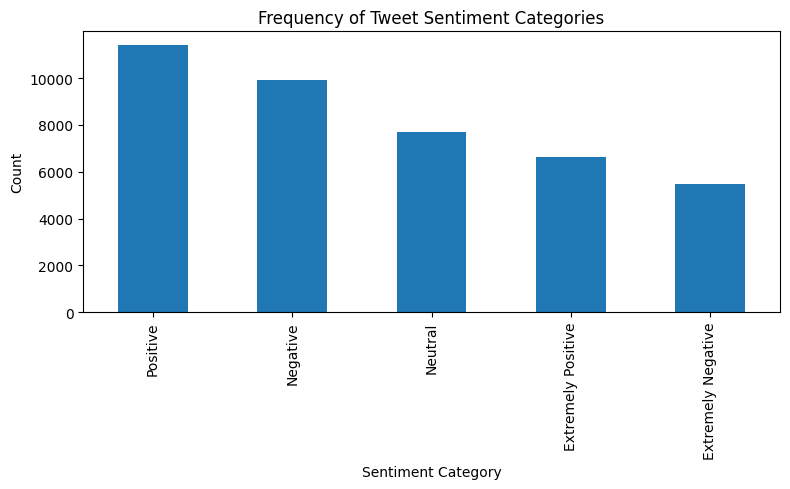

,count
Sentiment,
Positive,11422
Negative,9917
Neutral,7713
Extremely Positive,6624
Extremely Negative,5481


In [10]:
#ZADATAK: Provjerite broj ponavljanja svake od kategorija tweetova te ih prikžite na grafu koristeći prikladne biblioteke
df = pd.read_csv('covid_dataset/Corona_NLP_train.csv', encoding='latin1')
counts = df['Sentiment'].value_counts()

plt.figure(figsize=(8,5))
counts.plot(kind='bar')
plt.xlabel("Sentiment Category")
plt.ylabel("Count")
plt.title("Frequency of Tweet Sentiment Categories")
plt.tight_layout()
plt.show()

counts

In [11]:
mapping = {
    'Positive': 'Positive',
    'Extremely Positive': 'Positive',
    'Negative': 'Negative',
    'Extremely Negative': 'Negative',
    'Neutral': 'Neutral'
}

selected_features_train['Sentiment'] = selected_features_train['Sentiment'].map(mapping)
selected_features_test['Sentiment'] = selected_features_test['Sentiment'].map(mapping)

#ZADATAK: Prikažite broj primjeraka u svakoj klasi nakon mapiranja

print("TRAIN SET - broj primjeraka po klasi:")
print(selected_features_train['Sentiment'].value_counts(), "\n")

print("TEST SET - broj primjeraka po klasi:")
print(selected_features_test['Sentiment'].value_counts())

TRAIN SET - broj primjeraka po klasi:
Sentiment
Positive    18046
Negative    15398
Neutral      7713
Name: count, dtype: int64 

TEST SET - broj primjeraka po klasi:
Sentiment
Negative    1633
Positive    1546
Neutral      619
Name: count, dtype: int64


/tmp/ipython-input-1996945483.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_features_train['Sentiment'] = selected_features_train['Sentiment'].map(mapping)
/tmp/ipython-input-1996945483.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_features_test['Sentiment'] = selected_features_test['Sentiment'].map(mapping)


### c) Lematizacija i čišćenje teksta

In [12]:
def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove mentions
    text = re.sub(r'@\w+', '', text)
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [13]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
  # ZADATAK: Napišite funkciju za lematizaciju teksta
    words = text.split()
    lemmas = [lemmatizer.lemmatize(w) for w in words]
    return " ".join(lemmas)

selected_features_train['clean_tweet'] = selected_features_train['OriginalTweet'].apply(lemmatize_text).apply(clean_text)
selected_features_test['clean_tweet'] = selected_features_test['OriginalTweet'].apply(lemmatize_text).apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
/tmp/ipython-input-1702656995.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_features_train['clean_tweet'] = selected_features_train['OriginalTweet'].apply(lemmatize_text).apply(clean_text)
/tmp/ipython-input-1702656995.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versu

### d) Pretvaranje teksta u vektore značajki (TF-IDF)

TF-IDF (Term Frequency–Inverse Document Frequency) je statistička metoda koja se koristi u obradi prirodnog jezika i pretraživanju informacija za procjenu koliko je određena riječ važna za jedan dokument u odnosu na veću zbirku dokumenata. TF-IDF kombinira dvije komponente:
1. Frekvencija pojma (TF): Mjeri koliko se puta riječ pojavljuje u dokumentu. Veća učestalost sugerira veću važnost. Ako se neki pojam često pojavljuje u dokumentu, vjerojatno je relevantan za sadržaj tog dokumenta.
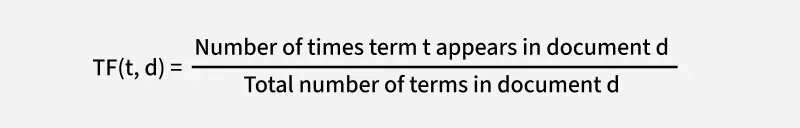

2. Obrnuta frekvencija dokumenta (IDF): Smanjuje težinu uobičajenih riječi koje se pojavljuju u više dokumenata, dok povećava težinu rijetkih riječi. Ako se pojam pojavljuje u manjem broju dokumenata, veća je vjerojatnost da je značajan i specifičan.
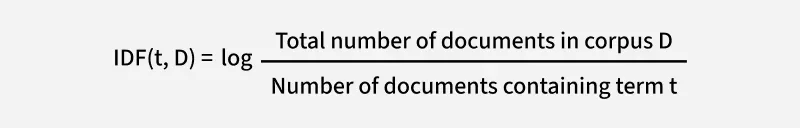

Ova ravnoteža omogućuje TF-IDF-u da istakne pojmove koji su i učestali unutar određenog dokumenta i prepoznatljivi u odnosu na ostatak zbirke dokumenata, što ga čini korisnim alatom za zadatke poput rangiranja pretraživanja, klasifikacije teksta i izdvajanja ključnih riječi.

In [14]:
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

X_train = tfidf.fit_transform(selected_features_train['clean_tweet'])
#ZADATAK: Transformirati očišćene tekstualne tweetove u numeričku TF-IDF reprezentaciju na testnom skupu.
X_test = tfidf.transform(selected_features_test['clean_tweet'])

### e) Enkodiranje oznaka

In [15]:
le = LabelEncoder()

print(selected_features_train['Sentiment'].unique())

y_train = le.fit_transform(selected_features_train['Sentiment'])
y_test = le.transform(selected_features_test['Sentiment'])

y_train = pd.DataFrame(y_train, columns=['Sentiment'])
y_test = pd.DataFrame(y_test, columns=['Sentiment'])
y_train.head()

['Neutral' 'Positive' 'Negative']


,Sentiment
0,1
1,2
2,2
3,2
4,0


## 4. Treniranje modela - Naive Bayes

In [16]:
param_grid = {'alpha': [0.1, 0.5, 1.0, 2.0]}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(MultinomialNB(), param_grid, cv=skf, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best alpha:", grid.best_params_)
print("Best cross-val accuracy:", grid.best_score_)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

Best alpha: {'alpha': 0.1}
Best cross-val accuracy: 0.6764586498292324


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

In [17]:
model = MultinomialNB(alpha = 0.1)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MultinomialNB(alpha=0.1)

## 5. Evaluacija performansi

In [18]:
y_pred = model.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

    Negative       0.72      0.72      0.72      1633
     Neutral       0.63      0.20      0.30       619
    Positive       0.63      0.81      0.71      1546

    accuracy                           0.67      3798
   macro avg       0.66      0.57      0.58      3798
weighted avg       0.67      0.67      0.65      3798

Confusion Matrix:

[[1172   47  414]
 [ 192  122  305]
 [ 272   25 1249]]


## ZADATAK:
Trenirati model koristeći SVM i usporediti performanse s Naive Bayes-om.

In [19]:
svm_model = LinearSVC()

svm_model.fit(X_train, selected_features_train['Sentiment'])

svm_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(selected_features_test['Sentiment'], svm_pred))
print(classification_report(selected_features_test['Sentiment'], svm_pred))

Accuracy: 0.7769878883622959
              precision    recall  f1-score   support

    Negative       0.80      0.78      0.79      1633
     Neutral       0.66      0.64      0.65       619
    Positive       0.80      0.83      0.81      1546

    accuracy                           0.78      3798
   macro avg       0.75      0.75      0.75      3798
weighted avg       0.78      0.78      0.78      3798



SVM ima veću ukupnu točnost i općenito bolje rezultate za sve klase. Naive Bayes jako loše prepoznaje neutralne tweetove. SVM je prikladniji model za ovaj zadatak.

# Zadatak – samostalan rad na datasetu

### U ovom zadatku studenti će sami proći cijeli proces klasifikacije teksta koristeći metode strojnog učenja – od pripreme podataka do treniranja i usporedbe različitih modela.

Cilj je klasificirati opise proizvoda iz e-trgovine u jednu od četiri kategorije (Electronics, Household, Books, Clothing & Accessories).

### Koraci zadatka:

1. **Pregled dataseta**  
   - Preuzmite dataset „E-commerce Text Classification“ s Kaggle-a:  
     https://www.kaggle.com/datasets/saurabhshahane/ecommerce-text-classification  
   - Učitajte ga u Colab (npr. pomoću `pd.read_csv`)  
   - Prikažite osnovne informacije o datasetu

2. **Odabir značajki i čišćenje podataka**  
   - Provjerite i obradite nedostajuće vrijednosti
   - Uklonite duplikate ako postoje  
   - Po potrebi uravnotežite dataset (npr. undersampling/oversampling) – nije obavezno, ali je plus

3. **Predobrada teksta (čišćenje i lematizacija)**  
   - Pretvorite tekst u mala slova  
   - Uklonite HTML tagove, URL-ove, interpunkciju, brojeve, specijalne znakove  
   - Uklonite stop-riječi  
   - Provedite lematizaciju

4. **Pretvaranje teksta u vektore značajki**  
     - `TfidfVectorizer`
   - Podijelite podatke na train/test skup (80/20 ili 75/25)

5. **Enkodiranje oznaka (labela)**  
   - Pretvorite tekstualne kategorije u brojčane pomoću `LabelEncoder` ili `OneHotEncoder` (ovisno o modelu)

6. **Treniranje i usporedba modela**  
   
   
   Za svaki model:
   - Naučite model na trening skupu
   - Izmjerite performanse na test skupu: **accuracy, precision, recall, F1-score**
   - Nacrtajte **confusion matrix** i **classification report**
   - Ako stignete: Podesite hiperparametre (barem `GridSearchCV` ili `RandomizedSearchCV` na 2–3 parametra) za bolje rezultate

7. **Vizualizacija rezultata**  
   - Usporedite dva (ili više) modela u tablici i stupčastim grafom (accuracy, F1-score)
   
   - Ako koristite TF-IDF, pokažite 10–20 riječi s najvećim TF-IDF težinama po klasi (Iz riječi biste trebali zaključiti o kojoj klasi se radi)

8. **Zaključak i komentar rezultata**  
   - Koji model je bio bolji i zašto?
   - Koje su prednosti i nedostaci pristupa koje ste koristili?
   - Što biste još mogli isprobati da poboljšate rezultat (ideje za daljnje eksperimente)?
   - Koliko je predobrada teksta utjecala na performanse?


In [20]:
df = pd.read_csv('ecommerceDataset.csv', header=None)
df.columns = ['label', 'text']

print("Prvih 5 redaka:")
display(df.head())

print("\nShape (broj redaka, broj stupaca):", df.shape)

print("\nDistribucija klasa:")
print(df['label'].value_counts())


Prvih 5 redaka:


,label,text
0,Household,Paper Plane Design Framed Wall Hanging Motivat...
1,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x ..."
2,Household,SAF 'UV Textured Modern Art Print Framed' Pain...
3,Household,"SAF Flower Print Framed Painting (Synthetic, 1..."
4,Household,Incredible Gifts India Wooden Happy Birthday U...



Shape (broj redaka, broj stupaca): (50425, 2)

Distribucija klasa:
label
Household                 19313
Books                     11820
Electronics               10621
Clothing & Accessories     8671
Name: count, dtype: int64


In [21]:
print("Broj nedostajućih vrijednosti po stupcu:")
print(df.isnull().sum())

df = df.dropna(subset=['label', 'text'])

print("\nBroj duplikata prije uklanjanja:", df.duplicated().sum())
df = df.drop_duplicates()

Broj nedostajućih vrijednosti po stupcu:
label    0
text     1
dtype: int64

Broj duplikata prije uklanjanja: 22622


In [23]:
df['clean_text'] = (
    df['text']
    .apply(clean_text)
    .apply(lemmatize_text)
)

In [24]:
X = df['clean_text']
y = df['label']

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)



In [25]:
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

print("Klase:", label_encoder.classes_)

Klase: ['Books' 'Clothing & Accessories' 'Electronics' 'Household']


In [28]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train_enc)

nb_pred = nb_model.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test_enc, nb_pred, target_names=label_encoder.classes_))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test_enc, nb_pred))

Classification Report:

                        precision    recall  f1-score   support

                 Books       0.97      0.89      0.93      1251
Clothing & Accessories       0.95      0.98      0.96      1135
           Electronics       0.91      0.91      0.91      1062
             Household       0.91      0.95      0.93      2113

              accuracy                           0.93      5561
             macro avg       0.94      0.93      0.93      5561
          weighted avg       0.93      0.93      0.93      5561

Confusion Matrix:

[[1108   24   25   94]
 [   3 1108    4   20]
 [  12    3  968   79]
 [  17   32   61 2003]]


In [29]:
svm_model = LinearSVC()
svm_model.fit(X_train, y_train_enc)

svm_pred = svm_model.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test_enc, svm_pred, target_names=label_encoder.classes_))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test_enc, svm_pred))


Classification Report:

                        precision    recall  f1-score   support

                 Books       0.95      0.94      0.95      1251
Clothing & Accessories       0.97      0.98      0.98      1135
           Electronics       0.94      0.93      0.93      1062
             Household       0.95      0.96      0.96      2113

              accuracy                           0.95      5561
             macro avg       0.95      0.95      0.95      5561
          weighted avg       0.95      0.95      0.95      5561

Confusion Matrix:

[[1177   10   25   39]
 [   9 1110    2   14]
 [  19    7  986   50]
 [  31   13   36 2033]]


,Model,Accuracy,F1
0,Naive Bayes,0.932746,0.933085
1,SVM,0.954145,0.953358


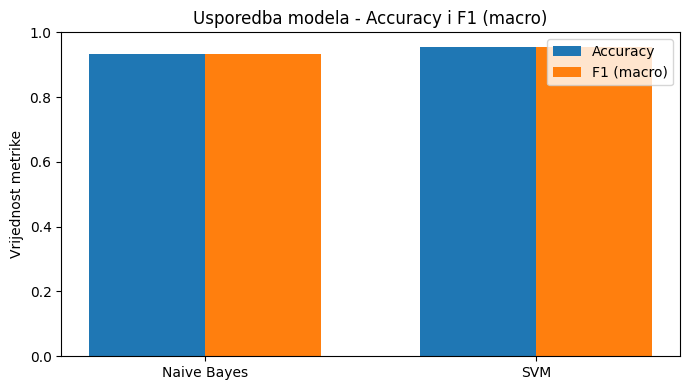

In [42]:
import numpy as np
width = 0.35
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'SVM'],
    'Accuracy': [
        accuracy_score(y_test_enc, nb_pred),
        accuracy_score(y_test_enc, svm_pred)
    ],
    'F1': [
        f1_score(y_test_enc, nb_pred, average='macro'),
        f1_score(y_test_enc, svm_pred, average='macro')
    ]
})

display(results)

x = np.arange(len(results))
width = 0.35

plt.figure(figsize=(7,4))
plt.bar(x - width/2, results['Accuracy'], width, label='Accuracy')
plt.bar(x + width/2, results['F1'], width, label='F1 (macro)')

plt.xticks(x, results['Model'])
plt.ylim(0, 1)
plt.ylabel('Vrijednost metrike')
plt.title('Usporedba modela - Accuracy i F1 (macro)')
plt.legend()
plt.tight_layout()
plt.show()




Na temelju dobivenih rezultata, SVM ostvario je bolju ukupnu točnost (0.95) u odnosu na Naive Bayes (0.93), uz istovremeno više vrijednosti macro i weighted F1-metrika.
SVM konzistentno postiže bolje rezultate u sve četiri kategorije, osobito u klasama Books, Electronics i Household

In [43]:
feature_names = np.array(tfidf.get_feature_names_out())

X_train_dense = X_train.tocsr()

for class_index, class_label in enumerate(label_encoder.classes_):
    idx = np.where(y_train_enc == class_index)[0]

    class_tfidf_mean = X_train_dense[idx].mean(axis=0).A1

    top_n = 15
    top_indices = class_tfidf_mean.argsort()[::-1][:top_n]

    print(f"\nTop {top_n} riječi za klasu '{class_label}':")
    for i in top_indices:
        print(feature_names[i], f"({class_tfidf_mean[i]:.4f})")



Top 15 riječi za klasu 'Books':
book (0.0697)
author (0.0511)
ha (0.0263)
wa (0.0237)
review (0.0205)
student (0.0198)
university (0.0198)
new (0.0192)
life (0.0188)
world (0.0175)
exam (0.0170)
story (0.0166)
india (0.0160)
year (0.0158)
science (0.0157)

Top 15 riječi za klasu 'Clothing & Accessories':
cotton (0.0649)
men (0.0474)
womens (0.0430)
wear (0.0360)
girl (0.0337)
fit (0.0325)
boy (0.0302)
fabric (0.0302)
look (0.0264)
woman (0.0250)
size (0.0243)
pack (0.0213)
soft (0.0207)
comfort (0.0205)
sock (0.0205)

Top 15 riječi za klasu 'Electronics':
camera (0.0364)
usb (0.0362)
cable (0.0293)
speaker (0.0257)
mm (0.0251)
black (0.0250)
gb (0.0250)
bluetooth (0.0249)
phone (0.0237)
device (0.0236)
laptop (0.0223)
card (0.0218)
audio (0.0217)
wireless (0.0210)
lens (0.0206)

Top 15 riječi za klasu 'Household':
set (0.0248)
steel (0.0241)
home (0.0223)
product (0.0201)
cm (0.0200)
stainless (0.0196)
table (0.0183)
color (0.0168)
easy (0.0165)
use (0.0164)
kitchen (0.0163)
water (0.